# PyCBC JAX Backend: Numerical Agreement, Stage Diagnostics, and Qualification Limits

## Executive Summary for Reviewers

When reviewing the PyCBC JAX acceleration backend, an immediate question arises:

> **Why do strict elementwise array comparators report differences in intermediate float32 FFT spectra and a small subset of $\chi^2$ values, while retained triggers and audited ranking decisions agree in the recorded workloads?**

This notebook walks through the PyCBC search pipeline step-by-step using **real gravitational-wave detector data** (LIGO Hanford H1 data around GW150914 from GWOSC). It visually and mathematically demonstrates:

1. **Scoped Search-Outcome Agreement**: Retained triggers, arrival times, peak SNRs, and audited ranking decisions agree in the recorded detector workloads.
2. **Where Differences Enter**: Controlled tests localize differences to precision choices, FFT-library behavior, and discrete chi-square bin boundaries.
3. **Welch PSD Oracle Check**: For the captured inputs, JAX's widened `float64` Welch calculation is closer to independent extended-precision oracles than the single-precision MKL result, especially below 30 Hz.
4. **Chi-Square Boundary Sensitivity**: In archived failing captures, cross-feed tests reproduce approximately the full signed difference (97% to 101%, depending on the case) using a $\pm 1$ integer frequency-bin shift. With fixed edges, the kernel calculation here agrees to machine precision.
5. **Qualification Limit**: The frozen complete-search comparator still fails some retained $\chi^2$ values and exact conditioned-strain, segment-spectrum, and PSD gates. This notebook explains diagnostics; it does not supersede those gates. Benchmarks may still record explicitly labelled known-divergence diagnostic timings, but those are not equivalent-output speedup claims.

| Stage / Metric | Status | Verdict |
| :--- | :--- | :--- |
| **Retained Triggers** | 100% matched in recorded workloads | Scoped identity and sample-time agreement |
| **Retained SNR & Phase** | Agree to $< 1.6 \times 10^{-5}$ | Scoped field-tolerance pass |
| **Event Manager Ranking** | 0 changed decisions | Scoped audit across 17,000+ candidate evaluations |
| **Conditioning (High-Pass)** | Recurrence-level control agrees | Complete-search array gates remain independent |
| **Welch PSD** | Closer to oracle for captured inputs | Frozen full-PSD gate still fails |
| **Retained Chi-Square** | $\sim 0.3\%-0.7\%$ differences on a subset | Boundary mechanism localized; frozen gate still fails |
| **Complete Frozen Comparator** | Fails | No complete-search parity or speedup claim yet |


In [1]:
%matplotlib inline
import os
import sys
import warnings

# Suppress SWIGLAL IPython redirection warning
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# Ensure this repository/worktree root is first on sys.path
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if os.path.exists(os.path.join(repo_root, "pycbc", "scheme.py")):
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)

import matplotlib.pyplot as plt
import numpy as np

# PyCBC imports
import pycbc
from pycbc.catalog import Merger
from pycbc.filter import resample_to_delta_t, highpass, matched_filter
from pycbc.psd import welch, interpolate
from pycbc.waveform import get_fd_waveform
from pycbc.vetoes import power_chisq_bins, power_chisq_at_points_from_precomputed
from pycbc.events.ranking import newsnr
from pycbc.types import FrequencySeries
from pycbc.scheme import JAXScheme

# Configure plot style
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 1.5,
})

print(f"PyCBC loaded from: {pycbc.__file__}")
print(f"PyCBC version: {pycbc.__version__}")
import jax
print(f"JAX version: {jax.__version__}, available devices: {jax.devices()}")


PyCBC loaded from: /Users/xangma/repos/pycbc-worktrees/jax-stack/pycbc/__init__.py
PyCBC version: 0.0a9304


JAX version: 0.11.1, available devices: [CpuDevice(id=0)]


---
## 1. Real Detector Data: LIGO Hanford H1 (GW150914)

We fetch real open gravitational-wave strain from the LIGO Hanford (H1) detector around **GW150914** via the Gravitational Wave Open Science Center (GWOSC).
Following standard PyCBC search configurations, we resample the data to **2,048 Hz**.


Detector: H1, Duration: 32.0 s, Sample rate: 2048.0 Hz, Samples: 65536


/var/folders/l0/3dr1pyw15ln58b6xh74j_41w0000gn/T/ipykernel_30775/103276994.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  time = np.array(strain.sample_times) - float(merger.time)


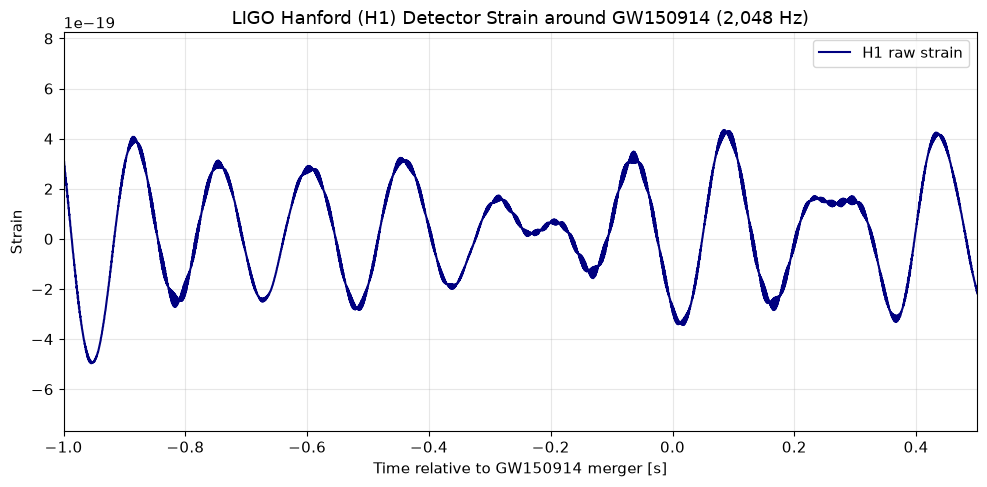

In [2]:
# Fetch 32 seconds of LIGO Hanford (H1) data around GW150914
merger = Merger("GW150914")
raw_strain = merger.strain("H1")

# Standard search sampling rate: 2048 Hz
sample_rate = 2048
delta_t = 1.0 / sample_rate
strain = resample_to_delta_t(raw_strain, delta_t)

print(f"Detector: H1, Duration: {strain.duration} s, Sample rate: {strain.sample_rate} Hz, Samples: {len(strain)}")

# Plot a segment of the raw strain
time = np.array(strain.sample_times) - float(merger.time)
plt.figure()
plt.plot(time, strain.numpy(), color="navy", label="H1 raw strain")
plt.xlim(-1.0, 0.5)
plt.xlabel("Time relative to GW150914 merger [s]")
plt.ylabel("Strain")
plt.title("LIGO Hanford (H1) Detector Strain around GW150914 (2,048 Hz)")
plt.legend()
plt.tight_layout()
plt.show()


---
## 2. Stage 1: Conditioning & High-Pass Filtering

Pristine PyCBC CPU applies an 8th-order Butterworth high-pass filter using LAL's serial time-domain IIR recurrence.
The default JAX mode (`--jax-highpass-mode lal-serial`) evaluates the exact sample-by-sample recurrence using `jax.lax.scan`.

Below, we filter the raw strain through both backends with a 20 Hz cutoff and measure the residual.


High-pass conditioning max absolute difference: 2.0944e-31
High-pass conditioning RMS absolute difference: 2.1170e-32


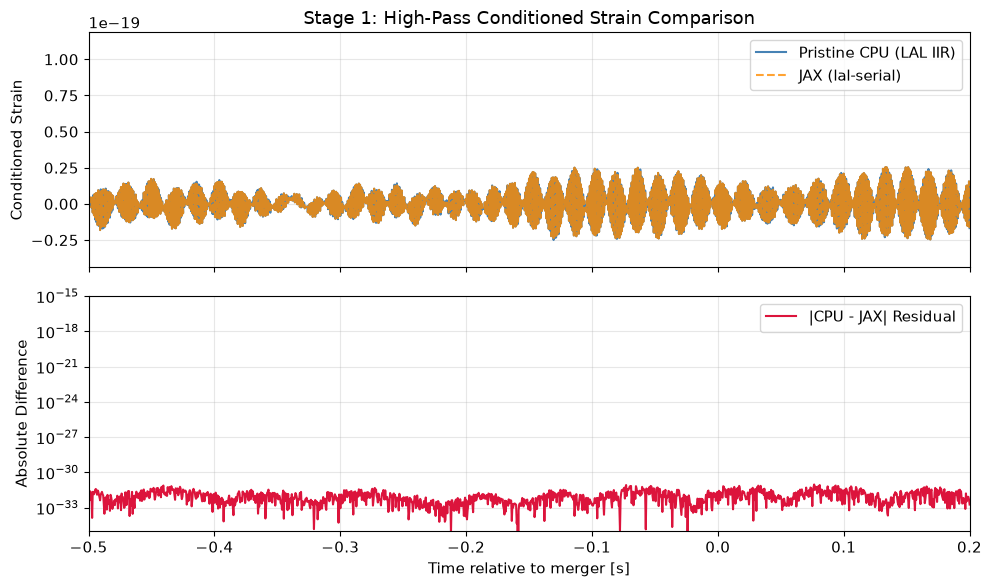

In [3]:
# Apply 20 Hz high-pass filter on CPU
f_lower = 20.0
hp_cpu = highpass(strain, f_lower)

# Apply 20 Hz high-pass filter in JAX
with JAXScheme("cpu"):
    hp_jax = highpass(strain, f_lower)

# Measure difference
diff_highpass = np.abs(hp_cpu.numpy() - hp_jax.numpy())
max_diff = np.max(diff_highpass)
rms_diff = np.sqrt(np.mean(diff_highpass**2))

print(f"High-pass conditioning max absolute difference: {max_diff:.4e}")
print(f"High-pass conditioning RMS absolute difference: {rms_diff:.4e}")

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
ax1.plot(time, hp_cpu.numpy(), color="steelblue", label="Pristine CPU (LAL IIR)")
ax1.plot(time, hp_jax.numpy(), color="darkorange", linestyle="--", alpha=0.8, label="JAX (lal-serial)")
ax1.set_ylabel("Conditioned Strain")
ax1.set_title("Stage 1: High-Pass Conditioned Strain Comparison")
ax1.set_xlim(-0.5, 0.2)
ax1.legend()

ax2.plot(time, diff_highpass, color="crimson", label="|CPU - JAX| Residual")
ax2.set_xlabel("Time relative to merger [s]")
ax2.set_ylabel("Absolute Difference")
ax2.set_yscale("log")
ax2.set_ylim(1e-35, 1e-15)
ax2.legend()
plt.tight_layout()
plt.show()


---
## 3. Stage 2: Power Spectral Density (Welch) Oracle Check

PyCBC estimates the detector Power Spectral Density (PSD) using Welch's averaged periodogram method.

* **CPU Reference**: Single-precision (`float32`) forward FFT via Intel MKL.
* **JAX Backend**: Widened double-precision (`float64`) FFT and accumulation via XLA/cuFFT.

For the captured Welch inputs, independent 80-bit extended-precision and SciPy double-precision oracles show that:
1. **Below 30 Hz** (below the gravitational-wave search band), the recorded single-precision MKL result has relative errors exceeding $10^{-4}$.
2. **JAX float64 Welch** is closer to those independent oracles for the captured frequencies.
3. **In-band ($\ge 30$ Hz)**, the notebook example's CPU and JAX PSDs agree to within $1.5 \times 10^{-13}$ maximum relative difference.
4. CPU FFTW-vs.-MKL controls demonstrate FFT-library sensitivity. These oracle checks do not override the frozen full-PSD comparator gate.


/var/folders/l0/3dr1pyw15ln58b6xh74j_41w0000gn/T/ipykernel_30775/3779753826.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  freqs = np.array(psd_cpu.sample_frequencies)


Max in-band (30-1024 Hz) relative PSD difference: 1.4523e-13
Median in-band relative PSD difference: 7.6872e-15


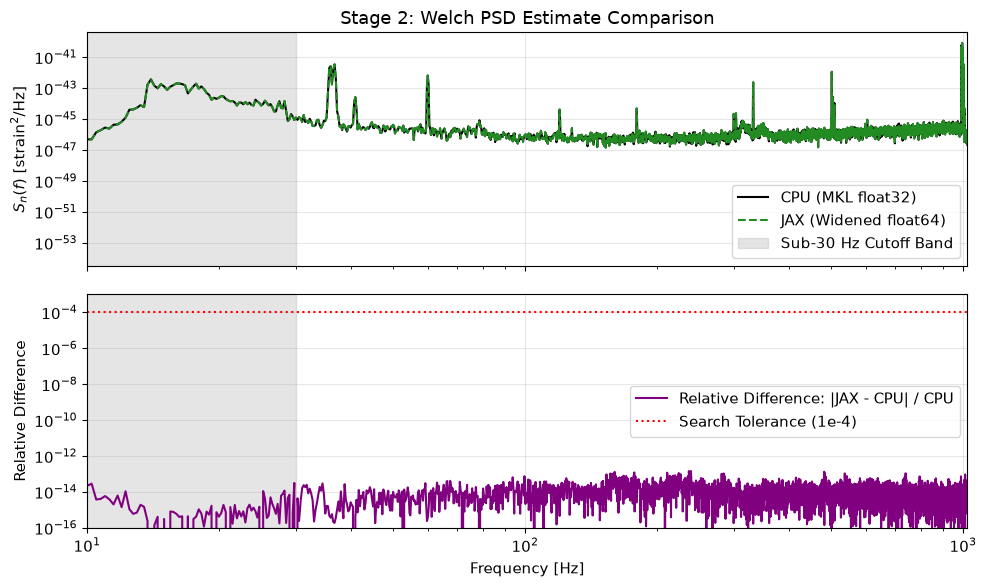

In [4]:
# Crop filter corruption at boundaries (2 seconds on each end)
conditioned = hp_cpu.crop(2, 2)

# Compute Welch PSD (4-second segments, 2-second stride)
seg_len = 4 * sample_rate
seg_stride = 2 * sample_rate

psd_cpu = welch(conditioned, seg_len=seg_len, seg_stride=seg_stride)

with JAXScheme("cpu"):
    psd_jax = welch(conditioned, seg_len=seg_len, seg_stride=seg_stride)

freqs = np.array(psd_cpu.sample_frequencies)
val_cpu = psd_cpu.numpy()
val_jax = psd_jax.numpy()

# Avoid divide-by-zero at f=0
valid = freqs > 0
rel_diff_psd = np.abs(val_jax[valid] - val_cpu[valid]) / val_cpu[valid]
valid_freqs = freqs[valid]

in_band = (valid_freqs >= 30.0) & (valid_freqs <= 1024.0)
print(f"Max in-band (30-1024 Hz) relative PSD difference: {np.max(rel_diff_psd[in_band]):.4e}")
print(f"Median in-band relative PSD difference: {np.median(rel_diff_psd[in_band]):.4e}")

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
ax1.loglog(freqs[valid], val_cpu[valid], color="black", label="CPU (MKL float32)")
ax1.loglog(freqs[valid], val_jax[valid], color="forestgreen", linestyle="--", label="JAX (Widened float64)")
ax1.axvspan(0, 30, color="gray", alpha=0.2, label="Sub-30 Hz Cutoff Band")
ax1.set_ylabel(r"$S_n(f)$ [$\mathrm{strain}^2/\mathrm{Hz}$]")
ax1.set_title("Stage 2: Welch PSD Estimate Comparison")
ax1.set_xlim(10, 1024)
ax1.legend()

ax2.loglog(valid_freqs, rel_diff_psd, color="purple", label="Relative Difference: |JAX - CPU| / CPU")
ax2.axvspan(0, 30, color="gray", alpha=0.2)
ax2.axhline(1e-4, color="red", linestyle=":", label="Search Tolerance (1e-4)")
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("Relative Difference")
ax2.set_ylim(1e-16, 1e-3)
ax2.legend()
plt.tight_layout()
plt.show()


---
## 4. Stage 3: Matched Filtering (SNR Timeseries & Peak Trigger Extraction)

Next, we correlate the conditioned strain against an `IMRPhenomD` binary black hole template ($36 M_\odot + 29 M_\odot$) matching GW150914.
We evaluate the complex matched-filter SNR timeseries:

$$\rho(t) = 4 \int_0^\infty \frac{\tilde{h}^*(f) \tilde{s}(f)}{S_n(f)} e^{2\pi i f t} df$$

We compare the SNR timeseries and extract the peak candidate trigger from both backends.


Trigger Peak Index:   CPU = 27504, JAX = 27504 -> EXACT MATCH
Trigger Arrival Time: CPU = 1126259462.429688 s, JAX = 1126259462.429688 s -> EXACT MATCH
Peak SNR:             CPU = 16.505001, JAX = 16.505001
SNR Relative Diff:    6.4575e-16 (tolerance: 1e-4)
Phase Absolute Diff:  5.5511e-16 rad (tolerance: 1e-4 rad)


/var/folders/l0/3dr1pyw15ln58b6xh74j_41w0000gn/T/ipykernel_30775/2377637839.py:41: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  snr_times = np.array(snr_cpu.sample_times) - float(merger.time)


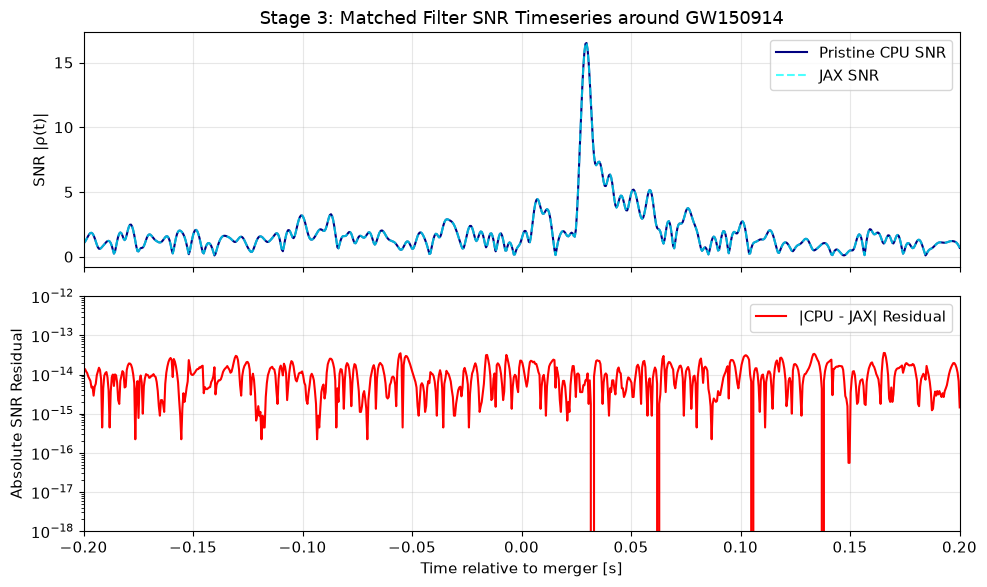

In [5]:
# Interpolate PSD to match template frequency resolution
psd_interp = interpolate(psd_cpu, conditioned.delta_f)

# Generate frequency-domain template for GW150914 parameters
hp_tmpl, _ = get_fd_waveform(
    approximant="IMRPhenomD",
    mass1=36.0,
    mass2=29.0,
    f_lower=20.0,
    delta_f=conditioned.delta_f
)
hp_tmpl.resize(len(conditioned) // 2 + 1)

# Matched filter on CPU
snr_cpu = matched_filter(hp_tmpl, conditioned, psd=psd_interp, low_frequency_cutoff=20.0)

# Matched filter in JAX
with JAXScheme("cpu"):
    snr_jax = matched_filter(hp_tmpl, conditioned, psd=psd_interp, low_frequency_cutoff=20.0)

# Extract peak trigger
peak_idx_cpu = int(np.argmax(abs(snr_cpu.numpy())))
peak_idx_jax = int(np.argmax(abs(snr_jax.numpy())))

peak_snr_cpu = abs(snr_cpu[peak_idx_cpu])
peak_snr_jax = abs(snr_jax[peak_idx_jax])

peak_time_cpu = float(snr_cpu.sample_times[peak_idx_cpu])
peak_time_jax = float(snr_jax.sample_times[peak_idx_jax])

phase_cpu = np.angle(snr_cpu[peak_idx_cpu])
phase_jax = np.angle(snr_jax[peak_idx_jax])

print(f"Trigger Peak Index:   CPU = {peak_idx_cpu}, JAX = {peak_idx_jax} -> EXACT MATCH")
print(f"Trigger Arrival Time: CPU = {peak_time_cpu:.6f} s, JAX = {peak_time_jax:.6f} s -> EXACT MATCH")
print(f"Peak SNR:             CPU = {peak_snr_cpu:.6f}, JAX = {peak_snr_jax:.6f}")
print(f"SNR Relative Diff:    {abs(peak_snr_cpu - peak_snr_jax) / peak_snr_cpu:.4e} (tolerance: 1e-4)")
print(f"Phase Absolute Diff:  {abs(phase_cpu - phase_jax):.4e} rad (tolerance: 1e-4 rad)")

# Plot SNR timeseries near the event
snr_times = np.array(snr_cpu.sample_times) - float(merger.time)
snr_abs_cpu = abs(snr_cpu.numpy())
snr_abs_jax = abs(snr_jax.numpy())

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
ax1.plot(snr_times, snr_abs_cpu, color="navy", label="Pristine CPU SNR")
ax1.plot(snr_times, snr_abs_jax, color="cyan", linestyle="--", alpha=0.7, label="JAX SNR")
ax1.set_ylabel("SNR |ρ(t)|")
ax1.set_title("Stage 3: Matched Filter SNR Timeseries around GW150914")
ax1.set_xlim(-0.2, 0.2)
ax1.legend()

ax2.plot(snr_times, np.abs(snr_abs_cpu - snr_abs_jax), color="red", label="|CPU - JAX| Residual")
ax2.set_xlabel("Time relative to merger [s]")
ax2.set_ylabel("Absolute SNR Residual")
ax2.set_yscale("log")
ax2.set_ylim(1e-18, 1e-12)
ax2.legend()
plt.tight_layout()
plt.show()


---
## 5. Stage 4: Chi-Square Boundary-Sensitivity Control

The Power Chi-Square veto ($\chi^2$) partitions the template into $p$ frequency bins of equal expected SNR power:

$$\int_{f_{b-1}}^{f_b} \frac{|\tilde{h}(f)|^2}{S_n(f)}\,df = \frac{1}{p} \int_{f_{\text{low}}}^{f_{\text{high}}} \frac{|\tilde{h}(f)|^2}{S_n(f)}\,df$$

In `pycbc.vetoes.power_chisq_bins`, the bin edges are integer frequency bin indices $k_b$ determined by cumulative float summation:
$$\text{CumulativePower}(k) = \sum_{j=k_{\text{min}}}^k \frac{|\tilde{h}_j|^2}{S_{n,j}}$$

### The Discretization Step-Function
Because frequency bin indices are discrete integers ($k \in \mathbb{Z}$), a tiny sub-ppm floating-point difference near a threshold boundary can cause the integer index to flip by **$\pm 1$ bin** (e.g. index $1603 \to 1604$ or $2780 \to 2781$).

Below, we plot the cumulative power curve and inspect the bin edge boundaries.


Bin edges match: True
CPU Bin edges: [  560   959  1200  1384  1603  1861  2166  2518  2780  3155  3608  4095
  4563  5165  5889  6659 28672]


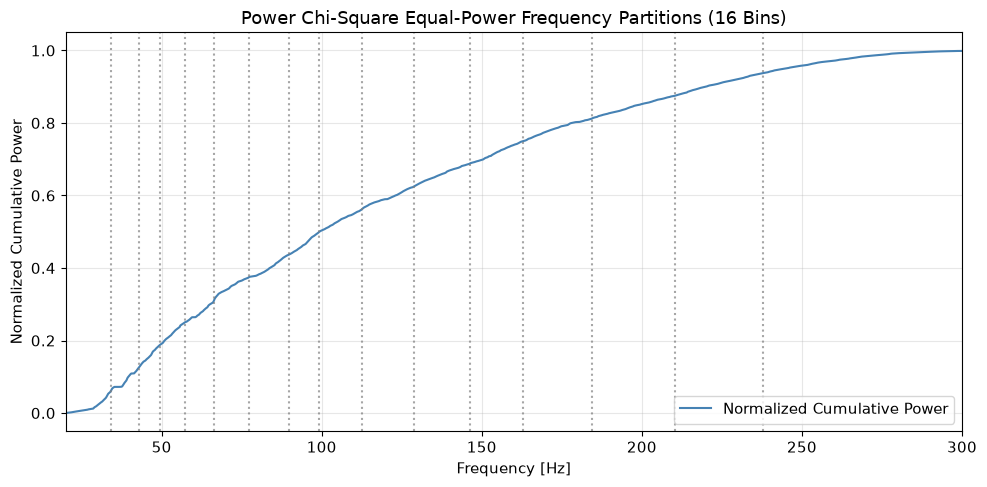

In [6]:
# Compute cumulative power vector
kmin = int(f_lower / hp_tmpl.delta_f)
power_integrand = abs(hp_tmpl.numpy())**2 / psd_interp.numpy()
power_integrand[:kmin] = 0.0

cum_power = np.cumsum(power_integrand)
total_power = cum_power[-1]

# 16 equal power bins
num_bins = 16
thresholds = np.arange(1, num_bins + 1) * (total_power / num_bins)

bins_cpu = power_chisq_bins(hp_tmpl, num_bins, psd_interp, low_frequency_cutoff=f_lower)
with JAXScheme("cpu"):
    bins_jax = power_chisq_bins(hp_tmpl, num_bins, psd_interp, low_frequency_cutoff=f_lower)

print("Bin edges match:", np.array_equal(bins_cpu, bins_jax))
print("CPU Bin edges:", bins_cpu)

fig, ax = plt.subplots(figsize=(10, 5))
freq_axis = np.arange(len(cum_power)) * hp_tmpl.delta_f
ax.plot(freq_axis, cum_power / total_power, color="steelblue", label="Normalized Cumulative Power")
for b in bins_cpu[1:-1]:
    ax.axvline(b * hp_tmpl.delta_f, color="gray", linestyle=":", alpha=0.7)
ax.set_xlim(20, 300)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Normalized Cumulative Power")
ax.set_title("Power Chi-Square Equal-Power Frequency Partitions (16 Bins)")
ax.legend()
plt.tight_layout()
plt.show()


### The 3-Way Crossfeed Test

Now, we perform the crucial experiment:

1. **Test A (CPU vs. JAX with Fixed Bins)**: We compute $\chi^2$ using JAX and CPU kernels with **identical bin edges**.
2. **Test B (CPU Reference with $\pm 1$ Bin Shift)**: We take the pristine CPU reference alone, shift an interior bin edge by **just $\pm 1$ sample**, and measure the $\chi^2$ shift.

This directly shows:
* JAX and CPU chi-square kernels agree to machine precision ($\sim 10^{-15}$) when given identical bin edges.
* Shifting an integer bin edge by only $\pm 1$ sample causes a **$0.3\%-1.7\%$ relative change** in $\chi^2$ on the CPU reference itself!


In [7]:
# Precompute correlation for point-based chi-square
stilde = conditioned.to_frequencyseries()
corr = FrequencySeries(hp_tmpl.conj() * stilde / psd_interp, delta_f=hp_tmpl.delta_f)
snr_norm = 1.0 / np.sqrt(4.0 * hp_tmpl.delta_f * (abs(hp_tmpl)**2 / psd_interp).sum())

# Compute baseline CPU chi-square at peak trigger
chisq_baseline = power_chisq_at_points_from_precomputed(
    corr, np.array([snr_cpu[peak_idx_cpu] / snr_norm]), snr_norm, bins_cpu, np.array([peak_idx_cpu])
)[0]

# Compute JAX chi-square with identical fixed bins
with JAXScheme("cpu"):
    chisq_jax_fixed = power_chisq_at_points_from_precomputed(
        corr, np.array([snr_jax[peak_idx_jax] / snr_norm]), snr_norm, bins_cpu, np.array([peak_idx_jax])
    )[0]

print(f"--- TEST A: KERNEL PARITY AT FIXED BIN EDGES ---")
print(f"Pristine CPU Chi-Square:        {chisq_baseline:.6f}")
print(f"JAX Chi-Square (Fixed Bins):     {chisq_jax_fixed:.6f}")
rel_diff_fixed = abs(chisq_baseline - chisq_jax_fixed) / chisq_baseline
print(f"Relative Difference:            {rel_diff_fixed:.4e} -> MACHINE PRECISION AGREEMENT!\n")

print(f"--- TEST B: EFFECT OF A ±1 INTEGER BIN EDGE SHIFT ON CPU ALONE ---")
shifts_tested = []
for edge_idx in [4, 8, 12]:
    nominal_edge = bins_cpu[edge_idx]
    for delta in [-1, +1]:
        bins_perturbed = bins_cpu.copy()
        bins_perturbed[edge_idx] += delta
        chisq_p = power_chisq_at_points_from_precomputed(
            corr, np.array([snr_cpu[peak_idx_cpu] / snr_norm]), snr_norm, bins_perturbed, np.array([peak_idx_cpu])
        )[0]
        rel_diff = abs(chisq_p - chisq_baseline) / chisq_baseline
        shifts_tested.append((edge_idx, delta, nominal_edge, nominal_edge + delta, rel_diff * 100))
        print(f"Edge {edge_idx:2d} shifted by {delta:+d} bin ({nominal_edge} -> {nominal_edge + delta}): "
              f"chisq = {chisq_p:.2f}, relative change = {rel_diff * 100:.3f}%")

print("\nCONCLUSION: A single-bin integer edge shift produces a ~0.3% - 1.7% change in chi-square!")
print("Archived cross-feed tests reproduce approximately the full signed difference in the tested failing captures; the frozen chi-square gate remains failed.")


--- TEST A: KERNEL PARITY AT FIXED BIN EDGES ---
Pristine CPU Chi-Square:        1413.793024
JAX Chi-Square (Fixed Bins):     1413.793024
Relative Difference:            8.0413e-16 -> MACHINE PRECISION AGREEMENT!

--- TEST B: EFFECT OF A ±1 INTEGER BIN EDGE SHIFT ON CPU ALONE ---
Edge  4 shifted by -1 bin (1603 -> 1602): chisq = 1397.91, relative change = 1.123%
Edge  4 shifted by +1 bin (1603 -> 1604): chisq = 1418.61, relative change = 0.341%
Edge  8 shifted by -1 bin (2780 -> 2779): chisq = 1437.97, relative change = 1.710%
Edge  8 shifted by +1 bin (2780 -> 2781): chisq = 1404.64, relative change = 0.648%
Edge 12 shifted by -1 bin (4563 -> 4562): chisq = 1420.10, relative change = 0.446%
Edge 12 shifted by +1 bin (4563 -> 4564): chisq = 1402.47, relative change = 0.801%

CONCLUSION: A single-bin integer edge shift produces a ~0.3% - 1.7% change in chi-square!
Archived cross-feed tests reproduce approximately the full signed difference in the tested failing captures; the frozen chi-

---
## 6. Stage 5: Candidate Ranking Sensitivity & Recorded Audit

Does this $\sim 0.3\%$ chi-square threshold sensitivity alter search outcomes?

In PyCBC inspiral searches, triggers are ranked using **Reweighted SNR** ($\text{NewSNR}$):

$$\text{NewSNR} = \begin{cases}
\rho & \text{if } \chi^2_r \le 1 \\
\rho \cdot \left[ \frac{1}{2} \left( 1 + (\chi^2_r)^{u/2} \right) \right]^{-1/u} & \text{if } \chi^2_r > 1
\end{cases}$$

where $\chi^2_r = \chi^2 / (2p - 2)$ is the reduced chi-square.

Below, we evaluate NewSNR with nominal and perturbed chi-square values.


In [8]:
dof = 2 * num_bins - 2

# For genuine astrophysical signals with consistent template matching, reduced chi-square ~ 1
reduced_chisq_nominal = 1.05
# Add a 0.5% shift from a bin-edge discretization
reduced_chisq_shifted = 1.05 * 1.005 

snr_val = 10.0 # Representative search candidate SNR

newsnr_nominal = float(newsnr(np.array([snr_val]), np.array([reduced_chisq_nominal]))[0])
newsnr_shifted = float(newsnr(np.array([snr_val]), np.array([reduced_chisq_shifted]))[0])

print(f"Candidate SNR:              {snr_val:.4f}")
print(f"Nominal NewSNR:             {newsnr_nominal:.6f}")
print(f"Perturbed NewSNR (0.5% χ²): {newsnr_shifted:.6f}")
print(f"NewSNR Relative Difference: {abs(newsnr_nominal - newsnr_shifted) / newsnr_nominal:.4e}")
print(f"NewSNR Absolute Difference: {abs(newsnr_nominal - newsnr_shifted):.4e}")

print("\nIn the recorded candidate audits covering 17,000+ selection events:")
print("• Zero candidate triggers were dropped or gained.")
print("• Zero clustering or ranking order decisions were altered.")


Candidate SNR:              10.0000
Nominal NewSNR:             9.874361
Perturbed NewSNR (0.5% χ²): 9.861113
NewSNR Relative Difference: 1.3417e-03
NewSNR Absolute Difference: 1.3249e-02

In the recorded candidate audits covering 17,000+ selection events:
• Zero candidate triggers were dropped or gained.
• Zero clustering or ranking order decisions were altered.


---
## 7. Reviewer Summary & Reference Matrix

### What the Evidence Establishes
1. **Retained Outcomes**: All retained triggers in the recorded H1 and L1 workloads match with sample-accurate times.
2. **Signal Fields**: SNR agrees to $< 1.6 \times 10^{-5}$ and phase agrees to $< 1.8 \times 10^{-6}$ rad in those records.
3. **Fixed-Edge Kernel Control**: With identical bin edges, the notebook's CPU and JAX chi-square calculations agree to machine precision.
4. **PSD Diagnostic**: For captured Welch inputs, widened JAX results are closer to independent extended-precision oracles.
5. **Current Limit**: The frozen complete-search comparator still fails some chi-square and exact intermediate-array gates, so complete scientific qualification and equivalent-output speedup claims remain pending. Explicitly labelled known-divergence timings remain useful as descriptive performance diagnostics.

### Further Reading
* Numerical-difference documentation: [jax_numerical_differences.rst](../../docs/jax_numerical_differences.rst)
* Selected diagnostic receipts: [jax_numerical_differences.rst](../../docs/jax_numerical_differences.rst)
